# Generative Flow Performance vs PCA Dimensionality

compares FlatCFM FlowMatching (FM) and NeuralODE (ODE) models trained at different
PCA dimensions (16-1024) on cosine logfc W2 mean gene W1 and MMD overlays the
theoretical reconstruction limit to show the gap between the limit and actual
model performance


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from flatcfm.analysis import run_benchmark_suite

DIMS = [16, 32, 64, 128, 256, 512, 1024]
RUNS_ROOT = Path("artifacts/runs")

MODEL_FAMILIES = {
    "FM": "sciplex_fm_deg_pca_d{dim}",
    "ODE": "sciplex_ode_deg_pca_d{dim}",
}
MODEL_COLORS = {"FM": "#4477AA", "ODE": "#228833"}

metrics = ["mean_gene_w1", "w2_squared", "cosine_log_fc", "mmd"]
group_columns = ["cell_type", "product_dose"]
reductions = ["unweighted_mean"]

metric_lower_is_better = {
    "mean_gene_w1": True,
    "w2_squared": True,
    "cosine_log_fc": False,
    "mmd": True,
}
metric_direction = {
    "mean_gene_w1": "↓",
    "w2_squared": "↓",
    "cosine_log_fc": "↑",
    "mmd": "↓",
}


In [2]:
# find available FM + ODE PCA experiments with predictions
available = []  # list of (family, dim, exp_name)
for family, template in MODEL_FAMILIES.items():
    for dim in DIMS:
        exp_name = template.format(dim=dim)
        exp_dir = RUNS_ROOT / exp_name
        if not exp_dir.is_dir():
            print(f"SKIP {family} d={dim}: no run directory")
            continue
        subdirs = sorted(d for d in exp_dir.iterdir() if d.is_dir())
        if not subdirs:
            print(f"SKIP {family} d={dim}: no run subdirectory")
            continue
        latest = subdirs[-1]
        if not (latest / "predictions" / "held_out" / "predictions.h5ad").exists():
            print(f"SKIP {family} d={dim}: no predictions")
            continue
        available.append((family, dim, exp_name))
        print(f"{family} d={dim}: ready")

available_experiments = [a[2] for a in available]
print(f"\n{len(available)} model(s) available")
if not available:
    raise RuntimeError(
        "no models available -- run scripts/check_fm_pca_sweep.py and scripts/check_ode_pca_sweep.py first"
    )


FM d=16: ready
FM d=32: ready
FM d=64: ready
FM d=128: ready
FM d=256: ready
FM d=512: ready
FM d=1024: ready
ODE d=16: ready
ODE d=32: ready
ODE d=64: ready
ODE d=128: ready
ODE d=256: ready
ODE d=512: ready
ODE d=1024: ready

14 model(s) available


In [3]:
# evaluate all models using benchmark suite (cached by prediction fingerprint)
import hashlib

CACHE_DIR = Path("artifacts/gen_flows_pca_sweep_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _predictions_fingerprint(experiments: list[str]) -> str:
    parts = []
    for exp in sorted(experiments):
        exp_dir = RUNS_ROOT / exp
        subdirs = sorted(d for d in exp_dir.iterdir() if d.is_dir())
        if not subdirs:
            continue
        pred_path = subdirs[-1] / "predictions" / "held_out" / "predictions.h5ad"
        if pred_path.exists():
            parts.append(f"{pred_path}:{pred_path.stat().st_mtime}")
    return hashlib.sha256("|".join(parts).encode()).hexdigest()[:12]


cache_key = _predictions_fingerprint(available_experiments)
per_group_cache = CACHE_DIR / f"per_group_{cache_key}.parquet"

if per_group_cache.exists():
    per_group = pd.read_parquet(per_group_cache)
    print(f"loaded cached results ({cache_key})")
else:
    result = run_benchmark_suite(
        {
            "experiments": available_experiments,
            "metrics": ["mean_gene_w1", "w2_squared", "cosine_log_fc"],
            "group_columns": group_columns,
            "reductions": reductions,
        }
    )
    result_mmd = run_benchmark_suite(
        {
            "experiments": available_experiments,
            "metrics": ["mmd"],
            "group_columns": group_columns,
            "reductions": reductions,
            "metric_spaces": [
                {"name": "train_pca_50", "kind": "train_pca", "pca_n_components": 50},
            ],
        }
    )
    per_group = pd.concat(
        [result["per_group_metrics"], result_mmd["per_group_metrics"]],
        ignore_index=True,
    )
    per_group.to_parquet(per_group_cache)
    print(f"saved results to cache ({cache_key})")

print(f"per group rows: {len(per_group)}")


/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/da

saved results to cache (0a9cae9e3d4c)
per group rows: 21000


In [4]:
# extract per-(family, dim) results
rows = []
for family, dim, exp_name in available:
    for metric in metrics:
        subset = per_group[(per_group["model_name"] == exp_name) & (per_group["metric_base"] == metric)]
        if subset.empty:
            subset = per_group[(per_group["model_name"] == exp_name) & (per_group["metric"] == metric)]
        if subset.empty:
            continue
        rows.append(
            {
                "family": family,
                "dim": dim,
                "metric": metric,
                "mean": subset["value"].mean(),
                "std": subset["value"].std(),
                "n_groups": len(subset),
            }
        )

results_df = pd.DataFrame(rows)
if not results_df.empty:
    for family in results_df["family"].unique():
        sub = results_df[results_df["family"] == family]
        print(f"\n{family}:")
        display(sub.pivot_table(index="dim", columns="metric", values="mean").round(4))



FM:


metric,cosine_log_fc,mean_gene_w1,mmd,w2_squared
dim,,,,
16,0.1585,0.2482,0.0598,2134.9046
32,0.1309,0.2454,0.0571,2156.2584
64,0.1242,0.2416,0.0548,2205.1740
128,0.1224,0.2413,0.0526,2275.3828
256,0.1093,0.2341,0.0533,2403.4810
512,0.0844,0.2230,0.0540,2618.8339
1024,0.0498,0.2177,0.0698,2967.2860



ODE:


metric,cosine_log_fc,mean_gene_w1,mmd,w2_squared
dim,,,,
16,0.1671,0.2431,0.0897,2123.7180
32,0.1570,0.2418,0.0906,2126.4061
64,0.1541,0.2425,0.0902,2129.9505
128,0.1064,0.2469,0.1542,2166.9518
256,0.0774,0.2555,0.2084,2207.1044
512,0.0848,0.2423,0.1518,2312.0247
1024,0.0716,0.2338,0.1419,2576.4377


In [5]:
# load theoretical limits from cache
theo_cache = Path("artifacts/theoretical_limits_cache/pca_results.json")
theo_df = None
if theo_cache.exists():
    theo_raw = json.loads(theo_cache.read_text())
    theo_all = pd.DataFrame(theo_raw)
    agg_dict = {
        "cosine_logfc_mean": ("cosine_logfc", "mean"),
        "w2_mean": ("w2", "mean"),
    }
    if "mean_gene_w1" in theo_all.columns:
        agg_dict["mean_gene_w1_mean"] = ("mean_gene_w1", "mean")
    if "mmd_pca50" in theo_all.columns:
        agg_dict["mmd_pca50_mean"] = ("mmd_pca50", "mean")
    theo_df = theo_all.groupby("latent_dim").agg(**agg_dict).reset_index().rename(columns={"latent_dim": "dim"})
    theo_df["w2_squared_mean"] = theo_df["w2_mean"] ** 2
    print(f"loaded theoretical limits for dims: {sorted(theo_df['dim'].unique())}")
else:
    print("no theoretical limit cache found -- run view_theoretical_limits.ipynb first")
    print("plots will show model performance only")


loaded theoretical limits for dims: [np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2000), np.int64(5000), np.int64(6396)]


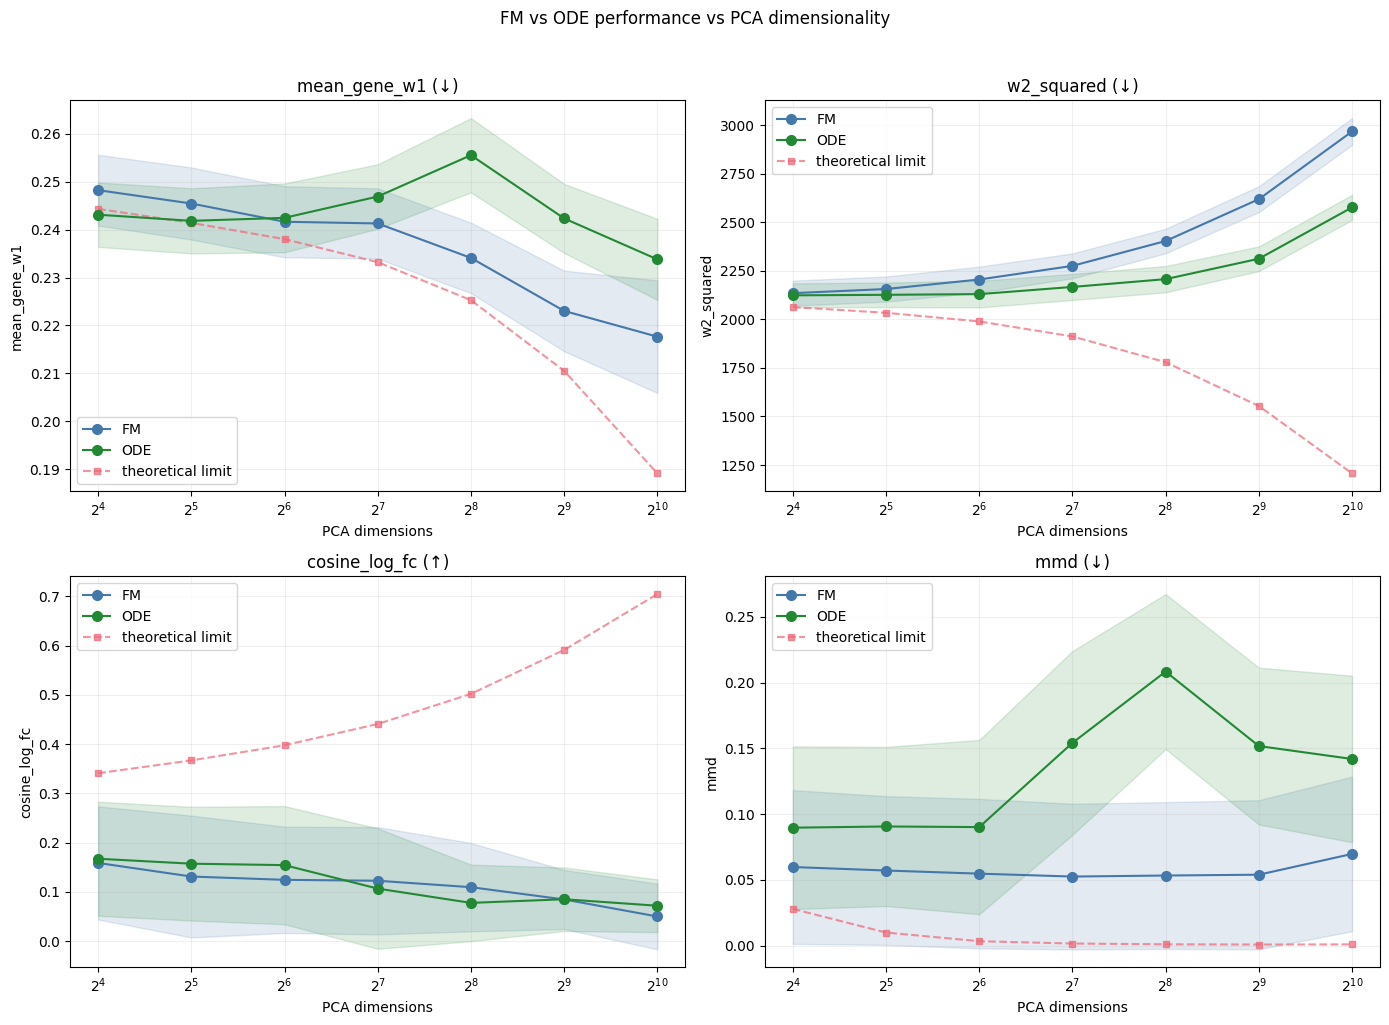

In [6]:
# plot FM vs ODE performance vs PCA dimension with theoretical limits
plot_metrics = [m for m in metrics if m in results_df["metric"].unique()]
n_metrics = len(plot_metrics)
ncols = 2
nrows = (n_metrics + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

theo_metric_map = {
    "cosine_log_fc": "cosine_logfc_mean",
    "w2_squared": "w2_squared_mean",
    "mean_gene_w1": "mean_gene_w1_mean",
    "mmd": "mmd_pca50_mean",
}

for ax_idx, metric in enumerate(plot_metrics):
    ax = axes[ax_idx]
    for family in MODEL_FAMILIES:
        mdf = results_df[(results_df["metric"] == metric) & (results_df["family"] == family)].sort_values("dim")
        if mdf.empty:
            continue
        color = MODEL_COLORS[family]
        ax.plot(
            mdf["dim"],
            mdf["mean"],
            marker="o",
            color=color,
            label=family,
            markersize=7,
            zorder=3,
        )
        ax.fill_between(
            mdf["dim"],
            mdf["mean"] - mdf["std"],
            mdf["mean"] + mdf["std"],
            alpha=0.15,
            color=color,
        )

    theo_col = theo_metric_map.get(metric)
    if theo_df is not None and theo_col is not None and theo_col in theo_df.columns:
        tdf = theo_df[theo_df["dim"].isin(DIMS)].sort_values("dim")
        if not tdf.empty:
            ax.plot(
                tdf["dim"],
                tdf[theo_col],
                marker="s",
                color="#EE6677",
                linestyle="--",
                label="theoretical limit",
                markersize=5,
                alpha=0.7,
            )

    direction = metric_direction.get(metric, "")
    ax.set_xlabel("PCA dimensions")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} ({direction})")
    ax.set_xscale("log", base=2)
    ax.legend()
    ax.grid(alpha=0.2)

for idx in range(n_metrics, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("FM vs ODE performance vs PCA dimensionality", y=1.02)
plt.tight_layout()
plt.show()



FM gap%:


metric,cosine_log_fc,mean_gene_w1,mmd,w2_squared
dim,,,,
16,53.5,1.6,113.8,3.5
32,64.3,1.7,472.1,6.0
64,68.7,1.5,1505.1,10.9
128,72.2,3.5,3124.7,19.0
256,78.2,3.9,4931.6,35.1
512,85.7,5.9,6005.0,68.5
1024,92.9,15.1,6945.0,145.8



ODE gap%:


metric,cosine_log_fc,mean_gene_w1,mmd,w2_squared
dim,,,,
16,51.0,-0.5,220.6,2.9
32,57.2,0.2,807.4,4.5
64,61.2,1.9,2542.2,7.1
128,75.8,5.9,9358.9,13.3
256,84.6,13.4,19555.1,24.0
512,85.7,15.1,17070.9,48.8
1024,89.8,23.6,14235.2,113.4


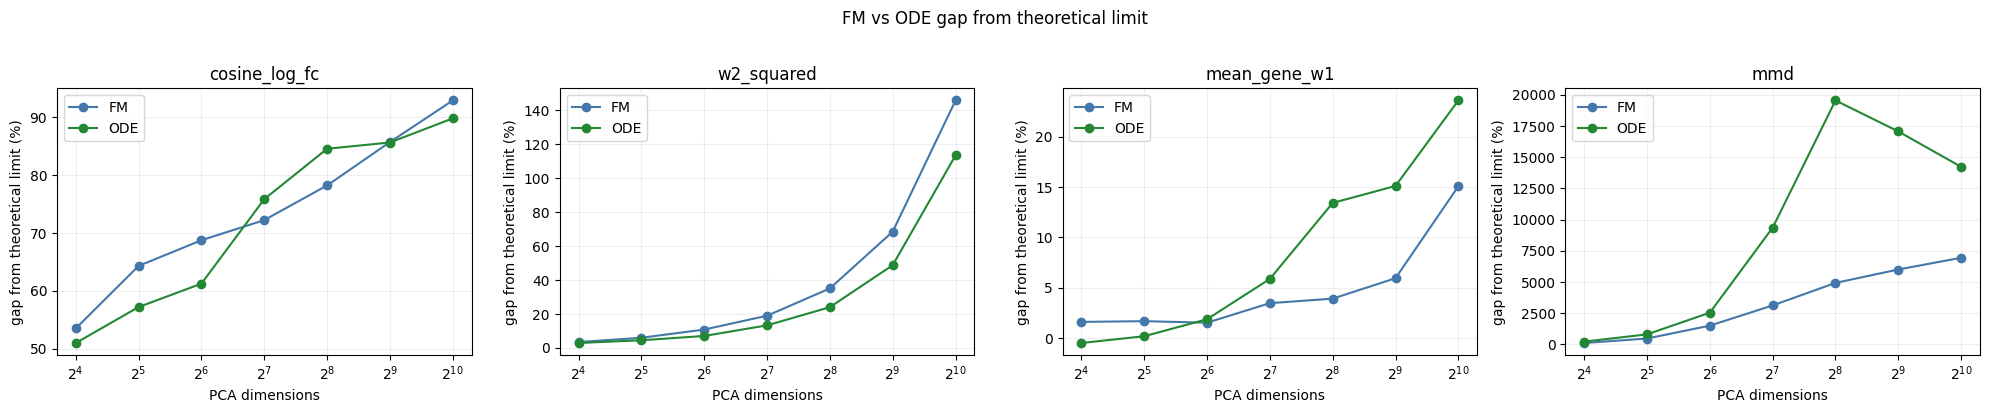

In [7]:
# gap analysis per family: how far is each model from the theoretical limit?
if theo_df is not None:
    gap_metrics = {k: v for k, v in theo_metric_map.items() if v in theo_df.columns}
    gap_rows = []
    for metric, theo_col in gap_metrics.items():
        for _, row in results_df[results_df["metric"] == metric].iterrows():
            dim = row["dim"]
            trow = theo_df[theo_df["dim"] == dim]
            if trow.empty:
                continue
            theo_val = trow[theo_col].iloc[0]
            model_val = row["mean"]
            lower = metric_lower_is_better.get(metric, True)
            if lower:
                gap_val = model_val - theo_val
            else:
                gap_val = theo_val - model_val
            gap_pct = gap_val / theo_val * 100 if theo_val else float("nan")
            gap_rows.append(
                {
                    "family": row["family"],
                    "dim": dim,
                    "metric": metric,
                    "value": model_val,
                    "limit": theo_val,
                    "gap": gap_val,
                    "gap_pct": gap_pct,
                }
            )

    if gap_rows:
        gap_df = pd.DataFrame(gap_rows)
        for family in gap_df["family"].unique():
            print(f"\n{family} gap%:")
            display(
                gap_df[gap_df["family"] == family].pivot_table(index="dim", columns="metric", values="gap_pct").round(1)
            )

        fig, axes = plt.subplots(1, len(gap_metrics), figsize=(5 * len(gap_metrics), 4), squeeze=False)
        for ax, metric in zip(axes[0], gap_metrics):
            for family in MODEL_FAMILIES:
                gdf = gap_df[(gap_df["metric"] == metric) & (gap_df["family"] == family)].sort_values("dim")
                if not gdf.empty:
                    ax.plot(
                        gdf["dim"],
                        gdf["gap_pct"],
                        marker="o",
                        label=family,
                        color=MODEL_COLORS[family],
                    )
            ax.set_xlabel("PCA dimensions")
            ax.set_ylabel("gap from theoretical limit (%)")
            ax.set_title(metric)
            ax.set_xscale("log", base=2)
            ax.legend()
            ax.grid(alpha=0.2)
        plt.suptitle("FM vs ODE gap from theoretical limit", y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("no theoretical limit data available for gap analysis")
